In [9]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import random
import pickle
import yaml

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
from pathlib import Path
from scipy.interpolate import PchipInterpolator, CubicSpline


class Config:
    DATA_PATH = Path("/scratch/phys/sin/rna-dataset")
    sample_sub = DATA_PATH / "sample_submission.csv"
    test_seq = DATA_PATH / "test_sequences.csv"
    train_labels = DATA_PATH / "train_labels.csv"
    train_sequences = DATA_PATH / "train_sequences.csv"
    validation_labels = DATA_PATH / "validation_labels.csv"
    validation_sequences = DATA_PATH / "validation_sequences.csv"
    model_config_path = "pairwise.yaml"
    pretrained_weights_path = "pytorch_model_fsdp.bin"
    save_weights_final = "final_ribonanza.pt"
    save_weights_name = "running_ribonanza.pt"
    
    max_len = 384
    batch_size = 1
    max_len_filter = 1000000
    min_len_filter = 10
    seed = 94

config = Config()

# Set seed for reproducibility
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.seed)

In [2]:
val_sequences = pd.read_csv(config.validation_sequences)
val_labels = pd.read_csv(config.validation_labels)
val_labels["pdb_id"] = val_labels.ID.str.rsplit('_', n=1, expand=True).iloc[:,0]

In [3]:
def plot_rna_3d_interactive(coords, title="RNA 3D Interactive", clip_percentile=None):
    # Accept torch tensor or numpy array
    if isinstance(coords, torch.Tensor):
        c = coords.detach().cpu().numpy()
    else:
        c = np.asarray(coords)

    # Handle [1, N, 3] -> [N, 3]
    if c.ndim == 3 and c.shape[0] == 1:
        c = c[0]

    # Optional robust clipping for huge outliers
    if clip_percentile is not None:
        lo = np.percentile(c, 100 - clip_percentile, axis=0)
        hi = np.percentile(c, clip_percentile, axis=0)
        c = np.clip(c, lo, hi)

    n = c.shape[0]
    residue_idx = np.arange(n)

    fig = go.Figure()

    # Backbone line
    fig.add_trace(
        go.Scatter3d(
            x=c[:, 0], y=c[:, 1], z=c[:, 2],
            mode="lines",
            line=dict(width=4, color="rgba(80,80,80,0.8)"),
            name="Backbone",
            hoverinfo="skip",
        )
    )

    # Residue points (colored by index)
    fig.add_trace(
        go.Scatter3d(
            x=c[:, 0], y=c[:, 1], z=c[:, 2],
            mode="markers",
            marker=dict(
                size=4,
                color=residue_idx,
                colorscale="Viridis",
                colorbar=dict(title="Residue"),
                opacity=0.95,
            ),
            text=[f"residue={i}<br>x={c[i,0]:.2f}<br>y={c[i,1]:.2f}<br>z={c[i,2]:.2f}" for i in range(n)],
            hovertemplate="%{text}<extra></extra>",
            name="Residues",
        )
    )

    fig.update_layout(
        title=title,
        template="plotly_white",
        width=900,
        height=700,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        legend=dict(x=0.02, y=0.98),
        margin=dict(l=0, r=0, t=45, b=0),
    )

    fig.show()


def plot_rna_3d(coords, sequence=None, title="RNA 3D Structure"):

    coords = np.asarray(coords)
    n = coords.shape[0]

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    colors = np.linspace(0, 1, n)

    sc = ax.scatter(
        coords[:, 0], coords[:, 1], coords[:, 2],
        c=colors, cmap='viridis', s=25
    )

    ax.plot(coords[:, 0], coords[:, 1], coords[:, 2], alpha=0.6)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    max_range = (coords.max(axis=0) - coords.min(axis=0)).max() / 2
    mid = coords.mean(axis=0)
    ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label("Residue index")

    plt.tight_layout()
    plt.show()

In [4]:
def making_data_dict(sequences_df: pd.DataFrame, labels_df: pd.DataFrame):
    grouped = labels_df.groupby("pdb_id")
    data = {}
    sequences, pdb_ids, all_xyz = [], [], []

    for pdb_id in tqdm(sequences_df["target_id"], desc="prepairing data"):
        if pdb_id not in grouped.groups:
            continue

        xyz = grouped.get_group(pdb_id)[["x_1", "y_1", "z_1"]].to_numpy(dtype="float32")

        sequence = list((sequences_df[sequences_df["target_id"]== pdb_id])["sequence"])[0]

        sequences.append(sequence)
        pdb_ids.append(pdb_id)
        all_xyz.append(xyz)
        
    data["pdb_ids"] = pdb_ids
    data["sequences"] = sequences
    data["all_xyz"] = all_xyz
    
    return data

#  Create Data Dictionaries
val_data_dict = making_data_dict(val_sequences, val_labels)

prepairing data: 100%|██████████| 28/28 [00:00<00:00, 143.21it/s]


In [5]:
class RNA3D_Dataset(Dataset):
    """
    A PyTorch Dataset for 3D RNA structures.
    """
    def __init__(self, data_dict, max_len=384):
        self.data = data_dict
        self.max_len = max_len
        self.nt_to_idx = {nt: i for i, nt in enumerate("ACGU")}

    def __len__(self):
        return len(self.data["sequences"])
    
    def __getitem__(self, idx):
        sequence = [self.nt_to_idx[nt] for nt in self.data["sequences"][idx]]
        sequence = torch.tensor(sequence, dtype=torch.long)
        xyz = torch.tensor(self.data["all_xyz"][idx], dtype=torch.float32)
        
        # If sequence is longer than max_len, randomly crop
        if len(sequence) > self.max_len:
            crop_start = np.random.randint(len(sequence) - self.max_len)
            crop_end = crop_start + self.max_len
            sequence = sequence[crop_start:crop_end]
            xyz = xyz[crop_start:crop_end]

        return {"sequence": sequence, "xyz": xyz}

# Create Dataset and DataLoaders
# inds_to_exclude = [3, 4, 6, 8, 11, 12, 13, 14, 18, 21, 22, 23]
val_dataset = RNA3D_Dataset(val_data_dict, max_len=config.max_len)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

In [10]:
from Network import RibonanzaNet


class Config:
    def __init__(self, **entries):
        self.__dict__.update(entries)
        self.entries = entries

    def print(self):
        print(self.entries)


def load_config_from_yaml(file_path):
    with open(file_path, 'r') as file:
        cfg = yaml.safe_load(file)
    return Config(**cfg)



#  Model Definition
class FinetunedRibonanzaNet(RibonanzaNet):
    def __init__(self, config_obj, pretrained=False, dropout=0.1):
        config_obj.dropout = dropout
        super(FinetunedRibonanzaNet, self).__init__(config_obj)

        if pretrained:
            self.load_state_dict(
                torch.load(config.pretrained_weights_path, map_location="cpu")
            )

        self.dropout = nn.Dropout(p=0.0)
        self.xyz_predictor = nn.Linear(256, 3)

    def forward(self, src):
        sequence_features, _ = self.get_embeddings(
            src, torch.ones_like(src).long().to(src.device)
        )
        xyz_pred = self.xyz_predictor(sequence_features)
        return xyz_pred



# Initialize Model
model_cfg = load_config_from_yaml(config.model_config_path)
model = FinetunedRibonanzaNet(model_cfg, pretrained=False).cuda()

constructing 9 ConvTransformerEncoderLayers


In [11]:
def calculate_distance_matrix(X, Y, epsilon=1e-4):
    return ((X[:, None] - Y[None, :])**2 + epsilon).sum(dim=-1).sqrt()


def dRMSD(pred_x, pred_y, gt_x, gt_y, epsilon=1e-4, Z=10, d_clamp=None):
    pred_dm = calculate_distance_matrix(pred_x, pred_y)
    gt_dm = calculate_distance_matrix(gt_x, gt_y)

    mask = ~torch.isnan(gt_dm)
    mask[torch.eye(mask.shape[0], device=mask.device).bool()] = False

    diff_sq = (pred_dm[mask] - gt_dm[mask])**2 + epsilon
    if d_clamp is not None:
        diff_sq = diff_sq.clamp(max=d_clamp**2)

    return diff_sq.sqrt().mean() / Z


def local_dRMSD(pred_x, pred_y, gt_x, gt_y, epsilon=1e-4, Z=10, d_clamp=30):
    pred_dm = calculate_distance_matrix(pred_x, pred_y)
    gt_dm = calculate_distance_matrix(gt_x, gt_y)

    mask = (~torch.isnan(gt_dm)) & (gt_dm < d_clamp)
    mask[torch.eye(mask.shape[0], device=mask.device).bool()] = False

    diff_sq = (pred_dm[mask] - gt_dm[mask])**2 + epsilon
    return diff_sq.sqrt().mean() / Z


def dRMAE(pred_x, pred_y, gt_x, gt_y, epsilon=1e-4, Z=10):
    pred_dm = calculate_distance_matrix(pred_x, pred_y)
    gt_dm = calculate_distance_matrix(gt_x, gt_y)

    mask = ~torch.isnan(gt_dm)
    mask[torch.eye(mask.shape[0], device=mask.device).bool()] = False

    diff = torch.abs(pred_dm[mask] - gt_dm[mask])
    return diff.mean() / Z


def align_svd_mae(input_coords, target_coords, Z=10):
    mask = ~torch.isnan(target_coords.sum(dim=-1))
    input_coords = input_coords[mask]
    target_coords = target_coords[mask]

    centroid_input = input_coords.mean(dim=0, keepdim=True)
    centroid_target = target_coords.mean(dim=0, keepdim=True)

    input_centered = input_coords - centroid_input
    target_centered = target_coords - centroid_target

    cov_matrix = input_centered.T @ target_centered
    U, S, Vt = torch.svd(cov_matrix)
    R = Vt @ U.T

    if torch.det(R) < 0:
        Vt_adj = Vt.clone()
        Vt_adj[-1, :] = -Vt_adj[-1, :]
        R = Vt_adj @ U.T

    aligned_input = (input_centered @ R.T) + centroid_target
    return torch.abs(aligned_input - target_coords).mean() / Z

In [ ]:
# Initialize Model
config.num_tta = 5
model_cfg = load_config_from_yaml(config.model_config_path)
model = FinetunedRibonanzaNet(model_cfg, pretrained=False)

best_loss = 1e20

for model_ckpt in range(20):
    model.load_state_dict(
        torch.load(f"running_model_{model_ckpt}.pt")
    )
    
    model.eval()
    val_loss = 0.0
    val_preds = []
    
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            sequence = batch["sequence"]
            gt_xyz = batch["xyz"].squeeze()
    
            pred_xyz = model(sequence).squeeze()
            loss = dRMAE(pred_xyz, pred_xyz, gt_xyz, gt_xyz)
            # print(f"[{i}] Loss: {loss:.4f} on sequence length {sequence.shape[-1]}")
            val_loss += loss.item()
    
            val_preds.append((gt_xyz.cpu().numpy(), pred_xyz.cpu().numpy()))
    
    val_loss /= len(val_loader)

    if val_loss < best_loss:
        best_loss = val_loss
        print(f"New best validation Loss: {val_loss:.4f} on model {model_ckpt}")

constructing 9 ConvTransformerEncoderLayers
New best validation Loss: 0.6773 on model 0
New best validation Loss: 0.6217 on model 2
New best validation Loss: 0.6019 on model 3
New best validation Loss: 0.5180 on model 4
New best validation Loss: 0.4912 on model 8
New best validation Loss: 0.4877 on model 10
New best validation Loss: 0.4813 on model 14
New best validation Loss: 0.4488 on model 18


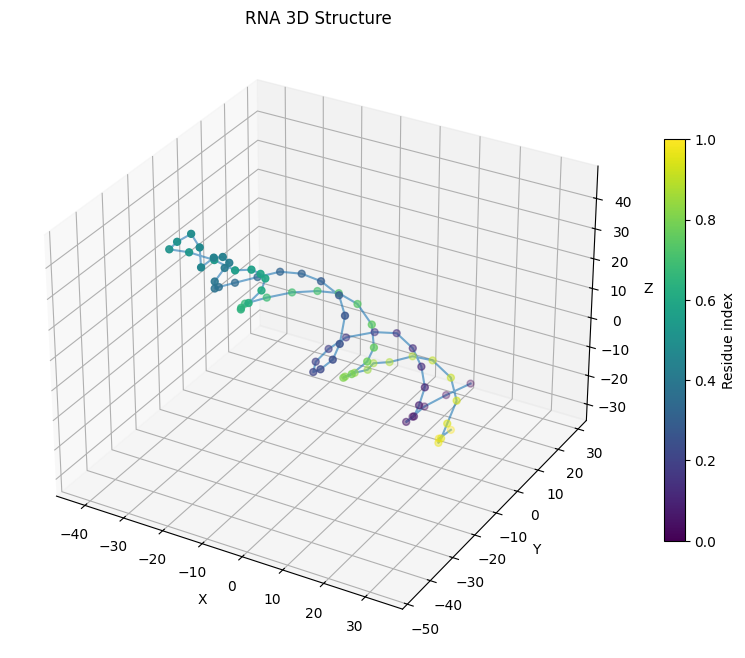

In [34]:
plot_rna_3d(val_preds[4][1])

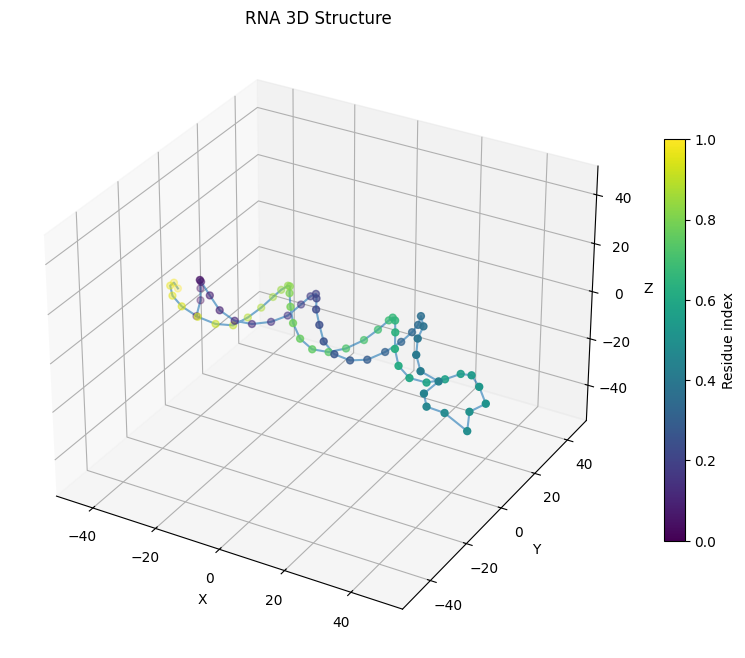

In [35]:
plot_rna_3d(val_preds[4][0])